<a href="https://colab.research.google.com/github/oluaptom-dev/DBN/blob/main/DSTNM_300426_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Differential Binary Noise Modulation

# v2:  


2) Esta é a técnica mais poderosa para o DSTNM. Você usa uma matriz de ruído unitária $\mathbf{U}$ para "embaralhar" as direções espaciais das antenas
Como adaptar: Gere uma matriz unitária aleatória $\mathbf{U}$ (usando a decomposição QR de uma matriz complexa aleatória).
Novo Alfabeto: $\mathcal{C}_{DSTNM} = \{ G_0 \mathbf{U}, G_1 \mathbf{U}, \dots, G_7 \mathbf{U} \}$.
Por que funciona: Como $\mathbf{U}$ é unitária, a propriedade $G^H G = \mathbf{I}$ é preservada.
A distância de produto é mantida: $|\det(G_i \mathbf{U} - G_j \mathbf{U})| = |\det(G_i - G_j) \cdot \det(\mathbf{U})| = |\det(G_i - G_j)|$, pois $|\det(\mathbf{U})| = 1$.
Resultado: As matrizes transmitidas perdem a aparência de Quatérnios e passam a parecer ruído puro, mas a relação de distância entre elas (o que garante o BER baixo) continua intacta.


## v1
1) Alterando a matri referencia X0 para [1 -1 ; 1 1] e nao a identidade = ok

2) Conferir se essa matriz apesar de alterara constelação resultante, mantem a estrutura de DISTANCIA DO CODIGO.

3) Iniciamente vou alterar o codigo para manter o H Ralingh e NOISE = 0
Quero ver como a distancia do produto minimo se conporta.

Para o futuro:
1) Usando eq 22 a distancia do codigo é distancia do produto e se mantem com 4 para DSTM?


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate, stats, special
from scipy.special import erfc

In [6]:
# A segundo ideia agora é retirar o alfabeto e deixar ruido
#  alphabet -> noise_alphabet
# 1) A mudança da ancora (matriz identidade)
# 2) Alfabeto deve ser estatistico (não deve pertencer a um alfabeto fixo).


# Vamos gerar ao novo :    Quaternion Rotated Noise Codebook    C={Gi​Z}i=18​
# ==========================
# MATRIZES GERADORAS  = origem dos quaternios - ficará algo ponto de partida e talvez haja comparação
# ==========================
I = np.eye(2, dtype=complex)

g1 = np.array([[1j, 0],
               [0, -1j]], dtype=complex)

g2 = np.array([[0, -1],
               [1,  0]], dtype=complex)

g1g2 = g1 @ g2

# Alfabeto quaternionico
alphabet = [
    I, -I,
    g1, -g1,
    g2, -g2,
    g1g2, -g1g2
]

# ==========================
# FUNÇÃO DE NORMALIZAÇÃO
# ==========================
def normalize_fro(M):                                # só normaliza energia, não torna unitário.
    return M / np.linalg.norm(M, 'fro')

# ==========================
# GERAR BASE NOISE MATRIX
# ==========================




def generate_base_noise():
    # Gera ruído complexo
    A = np.random.randn(2,2) + 1j*np.random.randn(2,2)     # gera novo ruido "BASE" = NORMAL (0,1)
    # Q é puramente unitária: Q^H @ Q = I e |det(Q)| = 1
    Q, R = np.linalg.qr(A)
    return Q                 # nao vou normalizar para a potencia = 1 aqui  (1/ raiz(2)) Pode ter sido o erro de codigo anteriores
    # Como $Q$ é uma matriz unitária (derivada da decomposição QR), o seu determinante é sempre um número complexo com módulo igual a 1.
    # $$|\det(Q)| = 1$$
    # multiplicamos a matriz por um escalar $c$, o determinante é multiplicado por $c^n$  Logo fica: \det(Z) = \frac{1}{2} \det(Q)  = METADE DE Q


# ==========================
# GERAR NOISE CODEBOOK                                  # gerar o ALFABETO = CODEBOOK
# ==========================                            # usa a BASE para cada codigo
def generate_noise_codebook(Z_identidade):
    Z = generate_base_noise()   # base e normalizada
    ###############################################
    if Z_identidade:
      Z = np.eye(2)      # Alem dessa linha : alterar o X_prev = Z   para o X_prev = eq22

    ###############################################

    codebook = []

    for G in alphabet:          # para cada item do alfabeto cria un Nk
        Nk = G @ Z              # Nk = G @ Z
        # Nk = normalize_fro(Nk)  # nao é mais necessario pois agora usa função com Q,R
        # Duas matrizes unitarias gera SEMPRE uma matriz unitaria
        codebook.append(Nk)

    return codebook, Z

    # 1 Unitariedade: Como $G$ (do seu $Q_8$) é unitária e $Z$ (ruído QR) é unitária, então $(GZ)^H(GZ) = Z^H G^H G Z = Z^H I Z = I$.
    # 2 Distância de Produto Invariante:$$|\det(G_1 Z - G_2 Z)| = |\det((G_1 - G_2)Z)| = |\det(G_1 - G_2)| \cdot |\det(Z)|$$
    #  Como $|\det(Z)| = 1$, a distância entre as matrizes de ruído é exatamente a mesma que a distância entre as matrizes originais do seu alfabeto.
    #  Receptor tera :  $$Y_{curr} Y_{prev}^H \approx (H G_{curr} Z) (H G_{prev} Z)^H = H G_{curr} Z Z^H G_{prev}^H H^H = H G_{curr} G_{prev}^H H^H$$
                        # O $Z$ desaparece e a detecção funciona como se o ruído não existisse!

In [ ]:
ALTEREI O Z PARA SER IDENTIDADE


RETIRAR A LINHA NA DEFINIÇÃO DE Z FUNÇÃO E
     Z= EQ 22    (INICIO DO LOOP  E NO IF 100, 200...)


O ruido entra uma vez na X0 ou X_prev e assim a cada multiplicação (novo bloco de bits) é usado o Q8 assim o ruido é rotacionado. Se for usado o codebook (que contem Z )essa nova matriz teria ruido
vezes ruido se acumulando.

Sugestão foi usado X0 = Z  mas por que usa-se Eq22 e se usar (X0 = Z*Eq22)

Tem erro no momento com Z esta igual a BER do DSTM, e sem Z (false) a BER ficou mais baixa. (comparar a v1 com v2 e vê o que esta errado. Com 800k a v1 (so DSTM classina foi BOM) ).
 Adicionaro if e rodar novamento ambas

In [7]:
# TEste pode deletar
from numpy.linalg import matrix_power
A = np.random.randn(2,2) + 1j*np.random.randn(2,2) # gera novo ruido "BASE" = NORMAL (0,1)
Q, R = np.linalg.qr(A)                           #  com : Q^HQ=I  necessario para
Z = (1/np.sqrt(2))*Q                             # então Z^HZ= (1/2)​I    ok
print(Z)
############
X_prev =  (1/np.sqrt(4)) *np.array([[1,-1],[1,1]]) # Eq 22  (Pot=1 com raiz(4), apos essa normalização fica 0,5I )
Z = X_prev
#  outro caso
# rng = np.random.default_rng()
# H = (rng.standard_normal((1, 2)) + 1j * rng.standard_normal((1, 2))) / np.sqrt(2)  ## pot = 2 para ser potencia = 1 usar 2 e nao raiz(2)
# Z = H
############
# Qual a potencia?   É unitaria?
energia = np.linalg.norm(Z, 'fro')**2
print("")
print("A energia de Z = ",energia)
print("")
print("Verificando se Z^H*Z = I: ")
unitaria = Z.conj().T @ Z     # hermitiana  ou np.dot(Z.conj().T, Z)
print(np.around(unitaria,2))  #

[[-0.01782273-0.60950686j -0.00088678+0.35802647j]
 [-0.14437467+0.32762737j -0.26345599+0.54991563j]]

A energia de Z =  1.0

Verificando se Z^H*Z = I: 
[[0.5 0. ]
 [0.  0.5]]


# V1 = com melhora!

# DSTM corrigido

1) X0 foi atualizado para Eq 22.
2) Feito teste de valores . Simulação com 300K mostra bons resultados.
3) Verificar se o CANAL RAYLEIGH deve ser normalizado por 1/sqrt(2).
4) Verificar se normalizar ou deixar a unitaria a matriz X0 (faz diferença na BER).


Passos aqui. Verificar como o determinante do alfabeto ficou? Sugestão é em vez de usar um ruido base e multiplicar pelo Quaternios. E jogar um ruido no X0 e aumentar esse ruido até ficar bem ruim.

Outro passo é mudar a matriz X0 (eq 22) por outra. OU assocciar a matriz ruido completa.



In [8]:
def run_simulation_DSTNM(snr_db_range, num_blocks,Z_identidade):  # simular 500k = bom
# Alterado a matriz X_0 inicial de identidade para eq 22

    ser_diff = []
    ser_coh = []
    ber_diff = []
    ber_coh = []

    for i, snr_db in enumerate(snr_db_range):

        print(f"[{i+1}/{len(snr_db_range)}] SNR = {snr_db} dB")

        rho = 10**(snr_db / 10)      # ρ_t = ρ/2 (SNR/antena)   (rho é a SNR!). Duvida acho que o 2 aqui é para dividir por t antenas.
        sigma_w2 = 1.0 / (2*rho)    #  variância do ruído como inversamente proporcional ao SNR (ρ)
        ########### TESTE101 NA LINHA ABAIXO
        #sigma_w2 = 0     # teste é como se SNR fosse infinita -  Leva o ruido a ser insignificante


        errors_diff = 0
        errors_coh = 0
        errors_diff_BER = 0
        errors_coh_BER = 0
        valid_blocks = 0


        seed = 42 # Define a semente (pode ser qualquer número inteiro)
        rng = np.random.default_rng(seed)
        # Agora use rng.standard_normal ou rng.normal em vez de np.random.randn
        H = (rng.standard_normal((1, 2)) + 1j * rng.standard_normal((1, 2))) / np.sqrt(2)  # sqrt(2) é normatizar potencia.
                                                                        # standart_normal = sigma2 = 1 ai fica H=1 + 1 = 2
                                                                        # para variancia de H=2 ser unitaria divide por raiz(2)!



        ################# De DSTM para DSTNM
        #Z_identidade = True   # True leva o Z a identidade (mantem o codebook igual ao alphabet) e usa X_prev = Eq 22
                              # False leva o Z ruido e X_prev = Z
        codebook, Z = generate_noise_codebook(Z_identidade)   # Agora nao será Q8 e sim codebook a cada frame cada matriz é um ruido Nk
        X_prev = Z
        if Z_identidade:
          X_prev =  (1/np.sqrt(4)) *np.array([[1,-1],[1,1]]) # Eq 22  (Pot=1 com raiz(4), apos essa normalização fica 0,5I )
        ####################################

        noise = np.sqrt(sigma_w2/2) * (np.random.randn(1, 2) + 1j*np.random.randn(1, 2)) #normaliza a variancia total (real+imag)
        Y_prev = H @ X_prev + noise    # Canal Rayleigh + ruido AWGN


        skip_next = False  # controle do overhead extra



        for k in range(num_blocks):

            # ==========================
            # Troca de canal (block fading)
            # ==========================
            # Vai fazer esse proximo if a cada 100; 200; 300...  ou seja na troca a CADA 100 blocos ( L =100 foi definido) !!!!
            # Gera um novo canal, novo X_0 e novo Y_0 e tag "skip_nex" indica que
            if k % 100 == 0 and k > 0:       # (resto da divisão por 100)  E  (verifica se é ZERO )Logo é multiplo de 100!
                H = (np.random.randn(1, 2) + 1j*np.random.randn(1, 2)) / np.sqrt(2)


                ########## De DSTM para DSTNM
                #Z_identidade = True   # True leva o Z a identidade (mantem o codebook igual ao alphabet) e usa X_prev = Eq 22
                                # False leva o Z ruido e X_prev = Z
                codebook, Z = generate_noise_codebook(Z_identidade)   # Agora nao será Q8 e sim codebook a cada frame cada matriz é um ruido Nk
                X_prev = Z
                if Z_identidade:
                  X_prev =  (1/np.sqrt(4)) *np.array([[1,-1],[1,1]]) # Eq 22  (Pot=1 com raiz(4), apos essa normalização fica 0,5I )
                ##################################################################################################################

                noise = np.sqrt(sigma_w2/2) * (np.random.randn(1, 2) + 1j*np.random.randn(1, 2))
                Y_prev = H @ X_prev + noise

                skip_next = True
                continue    # pula o resto do codigo e vai proximo contagem! Ex tava em 100. Vai pra 101.

            # ==========================
            # bloco após reset (não detecta) Sera sempro o 101; 201; 301 ...
            # ==========================
            if skip_next:
                idx = np.random.randint(0, 8)
                G_true = alphabet[idx]

                ############################DE DSTM  PARA DSTNM TRANSMITE NO AR A MATRIZ COM RUIDO (o receptor usa a matriz original sem ruido)
                X_curr = X_prev @ G_true    #



                noise = np.sqrt(sigma_w2/2) * (np.random.randn(1, 2) + 1j*np.random.randn(1, 2))
                Y_curr = H @ X_curr + noise

                X_prev = X_curr
                Y_prev = Y_curr

                skip_next = False
                continue  # pula o resto do codigo e vai proximo contagem!
                # Veja que o valid_block só é contabilizado de 102 até 199
                #

            # ==========================
            # símbolo normal
            # ==========================
            idx = np.random.randint(0, 8)
            G_true = alphabet[idx]


            ##################### DE DSTM  PARA DSTNM TRANSMITE NO AR A MATRIZ COM RUIDO (o receptor usa a matriz original sem ruido)
            # No DSTNM, enviamos a matriz do codebook ruidoso

            G_noise = codebook[idx]       # vai ser usado para transmitir e para o detector COERENTE (diferencial usa o alfabeto original, pois o ruido se cancela)

            X_curr = X_prev @ G_true    #



            # No Transmissor: Use G_noise = codebook[idx].

            # Canal
            noise = np.sqrt(sigma_w2/2) * (np.random.randn(1, 2) + 1j*np.random.randn(1, 2))
            Y_curr = H @ X_curr + noise
            ####################################

            # ==========================
            # DETECTOR DIFERENCIAL (Eq. 16)
            # ==========================
            M = Y_curr.conj().T @ Y_prev  # (2x2)  M sozinho não é potencia! É matriz de correlação cruzada (curr e prev)!    "M = Memoria Diferencial"  = quanto o sinal mudou (em fase e amplitude)
            # DSTNM = # O Z contido em Y_curr e Y_prev se cancela aqui!

            metrics_diff = []
            for G in alphabet:     # vai testar cada uma das matrizes
                #val = np.real(np.trace(G.conj().T @ M))   # parece que .conj().T  gera erro na inversão de fase ao fazer o trace idx 2 ate 7 gera erro de 1/3 sem ruido sigma_w2 = 0
                val = np.real(np.trace(G @ M))

                metrics_diff.append(float(val))

            idx_hat_diff = np.argmax(metrics_diff)
            # print("metrics_diff = ", metrics_diff)

            # ==========================
            # DETECTOR COERENTE              ruido ou original? Usa o que foi transmitido (se Z esta no primeiro bloco X0 e é rotacionado = ruido rotacionado pelo ALFABETO entao receptor coe usa ALFABETO)
            # ==========================
            metrics_coh = []
            for G_true in alphabet:                  # G_noise in codebook    /   G_true = alphabet[idx]
                X_test =  X_prev @ G_true            # usa aqui o G
                diff_vec = Y_curr - H @ X_test
                val = -np.sum(np.abs(diff_vec)**2)
                metrics_coh.append(float(val))

            idx_hat_coh = np.argmax(metrics_coh)

            # ==========================
            # contagem de erros de simbolos
            # ==========================
            if idx_hat_diff != idx:
                errors_diff += 1

            if idx_hat_coh != idx:
                errors_coh += 1




            # Para simbolos = SER
            valid_blocks += 1              # Cada simbolo valido  (0 ate 99 = 100 simbolos, depois perde 100 e 101 e conta 102 até 199 = 98). Logo são 100+99+98+98+...




            # ==========================
            # contagem de erros de bit
            # ==========================
            # R = 1,5 é eficiencia expectral     (R = log2(M)/n) M numero de matrizes e n comprimento do bloco (t=2 e n=2)
            bit_errors_diff = bin(idx_hat_diff ^ idx).count('1')  #considerando 3 bits por símbolo
            errors_diff_BER += bit_errors_diff

            bit_errors_coh = bin(idx_hat_coh ^ idx).count('1')  #considerando 3 bits por símbolo
            errors_coh_BER += bit_errors_coh

            # Para bits = BER
            total_bits = 3 * valid_blocks  # Cada símbolo válido carrega 3 bits           Cada simbolo tem 3 bits

            #============================
            # atualização temporal
            X_prev = X_curr
            Y_prev = Y_curr


        ser_diff.append(errors_diff / valid_blocks)
        ser_coh.append(errors_coh / valid_blocks)

        ber_diff.append(errors_diff_BER / total_bits)
        ber_coh.append(errors_coh_BER / total_bits)

    print("✅ Simulação concluída!")

    return ser_diff, ser_coh, ber_diff, ber_coh

In [ ]:
# a, b, c, d = run_simulation_miso(snr_range, num_blocks=1)
TESTE AQUI SE DSTM PURA ESTA BOA,   ok  ok sempre comparar com v1.!!!!!!!!!!!!!!!!!! (veja que no final da uma queda rapida. )
rever com a v1. DEPOIS RESOLVA O PROBLEMA DE Z ..............

[1/7] SNR = 5.0 dB
[2/7] SNR = 7.5 dB
[3/7] SNR = 10.0 dB
[4/7] SNR = 12.5 dB
[5/7] SNR = 15.0 dB
[6/7] SNR = 17.5 dB
[7/7] SNR = 20.0 dB
✅ Simulação concluída!
[1/7] SNR = 5.0 dB
[2/7] SNR = 7.5 dB
[3/7] SNR = 10.0 dB
[4/7] SNR = 12.5 dB
[5/7] SNR = 15.0 dB
[6/7] SNR = 17.5 dB
[7/7] SNR = 20.0 dB
✅ Simulação concluída!


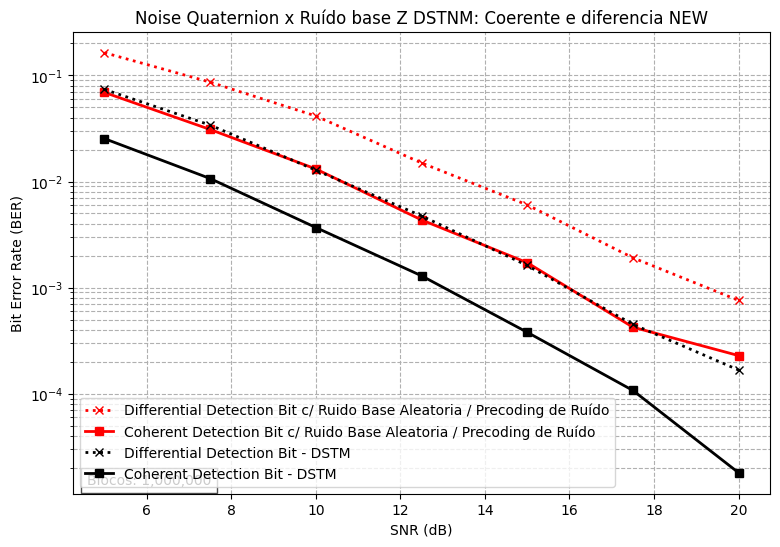

In [10]:
# --- Execução e Plotagem  DSTNM  ---

snr_range = np.arange(5, 21, 2.5)
num_blocks = 1000000

# Tecnica 2:  Introdução de uma Matriz de Base Aleatória (Precoding de Ruído
ser_diff, ser_coh, ber_diff, ber_coh =     run_simulation_DSTNM(snr_range, num_blocks, Z_identidade=True) # 10k=ruim / 100k=ok / 500k=bom   /  800k=Bom   / 1M+=artigo
                                                                                                            # 16s          2mi       12min      19min         36min

# DSTM Classiva
ser_diff2, ser_coh2, ber_diff2, ber_coh2 = run_simulation_DSTNM(snr_range, num_blocks, Z_identidade=False) # 10k=ruim / 100k=ok / 500k=ok    / 800k=Bom   / 1M+=artigo
                                                                                                            # 16s          2mi       12imn       19min    36min


plt.figure(figsize=(9,6))

#plt.semilogy(snr_range, ser_diff, 'r--s', linewidth=2, markersize=6, label='Differential Detection Simbolo')
#plt.semilogy(snr_range, ser_coh, 'b--o', linewidth=2, markersize=6, label='Coherent Detection Simbolo')
plt.semilogy(snr_range, ber_diff, 'r:x', linewidth=2, markersize=6, label='Differential Detection Bit c/ Ruido Base Aleatoria / Precoding de Ruído')
plt.semilogy(snr_range, ber_coh, 'r-s', linewidth=2, markersize=6, label='Coherent Detection Bit c/ Ruido Base Aleatoria / Precoding de Ruído')

plt.semilogy(snr_range, ber_diff2, 'k:x', linewidth=2, markersize=6, label='Differential Detection Bit - DSTM')
plt.semilogy(snr_range, ber_coh2, 'k-s', linewidth=2, markersize=6, label='Coherent Detection Bit - DSTM')





# Usamos 0.02 (2%) para não colar o texto exatamente na linha do gráfico
plt.text(0.02, 0.02, f'Blocos: {num_blocks:,d}',
         transform=plt.gca().transAxes,
         fontsize=10,
         color='black',
         bbox=dict(facecolor='white', alpha=0.7))
plt.grid(True, which="both", linestyle='--')
plt.xlabel('SNR (dB)')
plt.ylabel('Bit Error Rate (BER)')
plt.title('Noise Quaternion x Ruído base Z DSTNM: Coerente e diferencia NEW')
plt.legend()

plt.show()

In [ ]:
# Teste para saber como fica a nova constelaçao apos a entreada da matriz D  (já normalizada)
X_prev = (1/np.sqrt(4)) * np.array([[1,-1],[1,1]]) # Eq 22. / Pot = 1 / unitaria com X_0^H @ X_0 = 0,5I  (usar multiplicaçao matricial!)
for i in alphabet:
  print("Para i= " )
  print(i)
  print(X_prev @ i)
  print("#############")

Para i= 
[[1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]
[[ 0.5+0.j -0.5+0.j]
 [ 0.5+0.j  0.5+0.j]]
#############
Para i= 
[[-1.-0.j -0.-0.j]
 [-0.-0.j -1.-0.j]]
[[-0.5+0.j  0.5+0.j]
 [-0.5+0.j -0.5+0.j]]
#############
Para i= 
[[ 0.+1.j  0.+0.j]
 [ 0.+0.j -0.-1.j]]
[[0.+0.5j 0.+0.5j]
 [0.+0.5j 0.-0.5j]]
#############
Para i= 
[[-0.-1.j -0.-0.j]
 [-0.-0.j  0.+1.j]]
[[0.-0.5j 0.-0.5j]
 [0.-0.5j 0.+0.5j]]
#############
Para i= 
[[ 0.+0.j -1.+0.j]
 [ 1.+0.j  0.+0.j]]
[[-0.5+0.j -0.5+0.j]
 [ 0.5+0.j -0.5+0.j]]
#############
Para i= 
[[-0.-0.j  1.-0.j]
 [-1.-0.j -0.-0.j]]
[[ 0.5+0.j  0.5+0.j]
 [-0.5+0.j  0.5+0.j]]
#############
Para i= 
[[0.+0.j 0.-1.j]
 [0.-1.j 0.+0.j]]
[[0.+0.5j 0.-0.5j]
 [0.-0.5j 0.-0.5j]]
#############
Para i= 
[[-0.-0.j -0.+1.j]
 [-0.+1.j -0.-0.j]]
[[0.-0.5j 0.+0.5j]
 [0.+0.5j 0.+0.5j]]
#############


In [ ]:
# nao testei mas a ideia era um parametro para zerar Z ou nao  - usando interpolação desde I ate Z


# alpha = 0.0 -> Sistema DSTM Puro (Sem ruído, Z = Identidade)
# alpha = 1.0 -> Sistema DSTNM Total (Z = Totalmente aleatório)
alpha = 0.1  # Comece com 0.0 para testar a BER e vá aumentando

# 1. Gera a base aleatória unitária
A_rand = np.random.randn(2,2) + 1j*np.random.randn(2,2)
Z_rand, _ = np.linalg.qr(A_rand)

# 2. Interpolação para controle (O segredo está aqui)
# Criamos uma matriz que é "um pouco de identidade e um pouco de ruído"
Z_combined = (1 - alpha) * np.eye(2) + alpha * Z_rand

# 3. Re-ortogonaliza para garantir que X_prev continue unitária
# Isso é essencial para que o detector diferencial não exploda
Z, _ = np.linalg.qr(Z_combined)